<a href="https://colab.research.google.com/github/JulieBarny/Store_Sales_Kaggle/blob/origin-master/Store_Sales1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Store Sales - Time Series Forecasting**

*We import first the needed libraries*

In [1]:
import numpy
import pandas as pd
import seaborn as sns
import sklearn
from sklearn import linear_model
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


**1)** We will try to observ the tendencies



In [2]:
train_data = pd.read_csv("train.csv")
train_data["date"] = pd.to_datetime(train_data["date"])
plt.plot(train_data["date"] ,train_data["sales"])
plt.show()

ValueError: time data "201" doesn't match format "%Y-%m-%d", at position 329. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

The values are roughly close to the average, with two significant peaks.

In [3]:
holiday_df= pd.read_csv("holidays_events.csv")
holiday_df["date"] =pd.to_datetime(holiday_df["date"])

In [4]:
train_data = train_data.merge(holiday_df[["date" , "type"]], on = 'date' , how = 'left')
train_data.head(10)

,id,date,store_nbr,family,sales,onpromotion,type
0,0,2013-01-01,1.0,AUTOMOTIVE,0.0,0.0,Holiday
1,1,2013-01-01,1.0,BABY CARE,0.0,0.0,Holiday
2,2,2013-01-01,1.0,BEAUTY,0.0,0.0,Holiday
3,3,2013-01-01,1.0,BEVERAGES,0.0,0.0,Holiday
4,4,2013-01-01,1.0,BOOKS,0.0,0.0,Holiday
5,5,2013-01-01,1.0,BREAD/BAKERY,0.0,0.0,Holiday
6,6,2013-01-01,1.0,CELEBRATION,0.0,0.0,Holiday
7,7,2013-01-01,1.0,CLEANING,0.0,0.0,Holiday
8,8,2013-01-01,1.0,DAIRY,0.0,0.0,Holiday
9,9,2013-01-01,1.0,DELI,0.0,0.0,Holiday


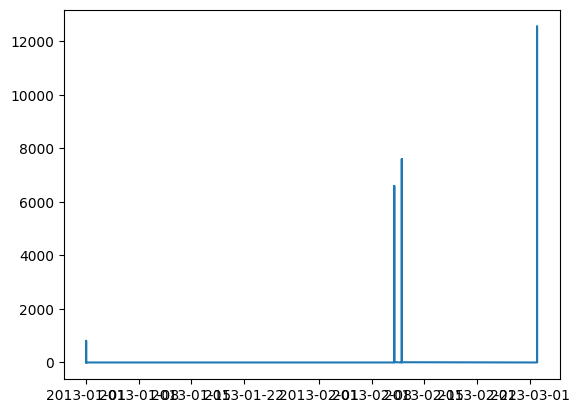

In [5]:

holiday_data = train_data[train_data["type"]== "Holiday"]
plt.plot( holiday_data["date"], holiday_data["sales"])

In [6]:

train_data = pd.get_dummies(train_data , columns = ['family' , 'type'])
print(train_data.columns)


Index(['id', 'date', 'store_nbr', 'sales', 'onpromotion', 'family_AUTOMOTIVE',
       'family_BABY CARE', 'family_BEAUTY', 'family_BEVERAGES', 'family_BOOKS',
       'family_BREAD/BAKERY', 'family_CELEBRATION', 'family_CLEANING',
       'family_DAIRY', 'family_DELI', 'family_EGGS', 'family_FROZEN FOODS',
       'family_GROCERY I', 'family_GROCERY II', 'family_HARDWARE',
       'family_HOME AND KITCHEN I', 'family_HOME AND KITCHEN II',
       'family_HOME APPLIANCES', 'family_HOME CARE', 'family_LADIESWEAR',
       'family_LAWN AND GARDEN', 'family_LINGERIE', 'family_LIQUOR,WINE,BEER',
       'family_MAGAZINES', 'family_MEATS', 'family_PERSONAL CARE',
       'family_PET SUPPLIES', 'family_PLAYERS AND ELECTRONICS',
       'family_POULTRY', 'family_PREPARED FOODS', 'family_PRODUCE',
       'family_SCHOOL AND OFFICE SUPPLIES', 'family_SEAFOOD', 'type_Holiday',
       'type_Work Day'],
      dtype='object')


In [7]:
train_data["day"] = train_data['date'].dt.day
train_data["month"] = train_data["date"].dt.month
train_data["dayofweek"] = train_data["date"].dt.dayofweek
train_data= train_data.drop(columns = ["date"] , axis = 1)

In [8]:
train_data[["onpromotion" , "store_nbr" , "day" ,"dayofweek" ,"month"]] = train_data[["onpromotion" , "store_nbr" , "day" ,"dayofweek" ,"month"]].fillna(0)
train_data[["onpromotion" , "store_nbr" , "day" ,"dayofweek" ,"month"]] = train_data[["onpromotion" , "store_nbr" , "day" ,"dayofweek" ,"month"]].astype(int)

In [9]:
print(train_data.dtypes)

id                                     int64
store_nbr                              int64
sales                                float64
onpromotion                            int64
family_AUTOMOTIVE                       bool
family_BABY CARE                        bool
family_BEAUTY                           bool
family_BEVERAGES                        bool
family_BOOKS                            bool
family_BREAD/BAKERY                     bool
family_CELEBRATION                      bool
family_CLEANING                         bool
family_DAIRY                            bool
family_DELI                             bool
family_EGGS                             bool
family_FROZEN FOODS                     bool
family_GROCERY I                        bool
family_GROCERY II                       bool
family_HARDWARE                         bool
family_HOME AND KITCHEN I               bool
family_HOME AND KITCHEN II              bool
family_HOME APPLIANCES                  bool
family_HOM

In [10]:

X = train_data.drop("sales" , axis = 1)
y= train_data["sales"]
X_train ,X_test , y_train,y_test = train_test_split(X,y , test_size =0.2 , random_state = 42)


We choose first Linear Regression

In [11]:
regression_model = linear_model.LinearRegression()
regression_model.fit(X_train , y_train)

ValueError: Input y contains NaN.

In [13]:
regression_model.score(X_test ,y_test)

0.5435921353875078

Our accuracy is pretty low around 0.54

**New model:** Ridge regression

In [14]:
from sklearn import linear_model

In [15]:
ridge_regression_model = linear_model.Ridge(alpha =0.5) # it is more for overfitting case because by reducing the weights it helps the model generalize better

In [16]:
ridge_regression_model.fit(X_train,y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=2.72701e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Ridge(alpha=0.5)

In [17]:
ridge_regression_model.score(X_test , y_test)

0.543592117026446

As we observed the ridge by adding an addtiionnal word to the linear regression model , we are just helping the model generalize better and then avoid overfitting . Here it is more underfitting

In [18]:
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
poly = PolynomialFeatures(degree= 2)
poly.fit_transform(X_train)
regression_model.fit(X_train , y_train)

In [ ]:
poly_test = PolynomialFeatures(degree = 2)
poly_test.fit_transform (X_test)
regression_model.score(X_test , y_test)

In [24]:
test_data = pd.read_csv("test.csv")
test_data = test_data.merge(holiday_df[["date" , "type"]], on = 'date' , how = 'left')
print(test_data)

            id        date  store_nbr                      family  onpromotion
0      3000888  2017-08-16          1                  AUTOMOTIVE            0
1      3000889  2017-08-16          1                   BABY CARE            0
2      3000890  2017-08-16          1                      BEAUTY            2
3      3000891  2017-08-16          1                   BEVERAGES           20
4      3000892  2017-08-16          1                       BOOKS            0
...        ...         ...        ...                         ...          ...
28507  3029395  2017-08-31          9                     POULTRY            1
28508  3029396  2017-08-31          9              PREPARED FOODS            0
28509  3029397  2017-08-31          9                     PRODUCE            1
28510  3029398  2017-08-31          9  SCHOOL AND OFFICE SUPPLIES            9
28511  3029399  2017-08-31          9                     SEAFOOD            0

[28512 rows x 5 columns]


In [25]:
test_data["date"]= pd.to_datetime(test_data["date"] , errors ="coerce")
test_data["day"] = test_data['date'].dt.day
test_data["month"] = test_data["date"].dt.month
test_data["dayofweek"] = test_data["date"].dt.dayofweek
test_data= test_data.drop(columns = ["date"] , axis = 1)

In [29]:
test_data = pd.get_dummies(test_data , columns = ['family'])
X_test = test_data.drop(columns = ["sales"] , axis = 1)

KeyError: "None of [Index(['family'], dtype='object')] are in the [columns]"

KeyError: "['sales'] not found in axis"

In [31]:
regression_model.predict(test_data)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- type_Additional
- type_Bridge
- type_Event
- type_Holiday
- type_Transfer
- ...
